# ============================================================
# CAPSTONE PROJECT
# NOTEBOOK 14: STRUCTURED MODEL ON EXPANDED 8-GENRE PILOT
# ============================================================
# Purpose:
# This notebook retrains the structured modelling branch using
# the expanded 8-genre pilot subset derived from FMA-Large.
#
# The goal is to:
# 1. Load the expanded pilot metadata
# 2. Retrieve matching engineered audio features
# 3. Train structured models on the expanded pilot
# 4. Select the best structured model
# 5. Save probabilities for expanded hybrid fusion
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print("Seeds set to:", SEED)

Seeds set to: 42


In [2]:
# ============================================================
# 2. LOAD EXPANDED PILOT METADATA
# ============================================================

pilot_df = pd.read_csv("../data/processed/audio_large_pilot_metadata_expanded.csv")

print("Expanded pilot metadata shape:", pilot_df.shape)
display(pilot_df.head())

print("\nClass distribution:")
print(pilot_df["genre_top"].value_counts())

print("\nSplit distribution:")
print(pilot_df["split"].value_counts())

Expanded pilot metadata shape: (3137, 5)


,track_id,genre_top,split,audio_path,audio_exists
0,171,Rock,training,../data/raw/audio/fma_large\000\000171.mp3,True
1,178,Rock,training,../data/raw/audio/fma_large\000\000178.mp3,True
2,189,Folk,training,../data/raw/audio/fma_large\000\000189.mp3,True
3,191,Folk,training,../data/raw/audio/fma_large\000\000191.mp3,True
4,205,Folk,training,../data/raw/audio/fma_large\000\000205.mp3,True



Class distribution:
genre_top
Rock            400
Folk            400
Experimental    400
Hip-Hop         400
Electronic      400
Pop             400
Instrumental    400
Classical       337
Name: count, dtype: int64

Split distribution:
split
training      2400
test           375
validation     362
Name: count, dtype: int64


In [3]:
# ============================================================
# 3. LOAD FEATURES TABLE
# ============================================================

features = pd.read_csv(
    "../data/raw/metadata/features.csv",
    header=[0, 1, 2],
    index_col=0
)

features.index = features.index.astype(int)

print("Features shape:", features.shape)

Features shape: (106574, 518)


In [4]:
# ============================================================
# 4. ALIGN FEATURES TO THE EXPANDED PILOT TRACKS
# ============================================================

pilot_df["track_id"] = pilot_df["track_id"].astype(int)

pilot_track_ids = pilot_df["track_id"].tolist()
features_pilot = features.loc[pilot_track_ids].copy()

# Reset index alignment for safety
pilot_df = pilot_df.reset_index(drop=True)
features_pilot = features_pilot.reset_index(drop=True)

print("Pilot-aligned features shape:", features_pilot.shape)
print("Recovered track IDs:", len(pilot_track_ids))
print("First few recovered track IDs:", pilot_track_ids[:5])

Pilot-aligned features shape: (3137, 518)
Recovered track IDs: 3137
First few recovered track IDs: [171, 178, 189, 191, 205]


In [5]:
# ============================================================
# 5. FLATTEN MULTIINDEX COLUMNS
# ============================================================

features_pilot.columns = [
    "_".join([str(level) for level in col]).strip()
    for col in features_pilot.columns.to_flat_index()
]

print("Flattened feature shape:", features_pilot.shape)
display(features_pilot.head())

Flattened feature shape: (3137, 518)


,chroma_cens_kurtosis_01,chroma_cens_kurtosis_02,chroma_cens_kurtosis_03,chroma_cens_kurtosis_04,chroma_cens_kurtosis_05,chroma_cens_kurtosis_06,chroma_cens_kurtosis_07,chroma_cens_kurtosis_08,chroma_cens_kurtosis_09,chroma_cens_kurtosis_10,...,tonnetz_std_04,tonnetz_std_05,tonnetz_std_06,zcr_kurtosis_01,zcr_max_01,zcr_mean_01,zcr_median_01,zcr_min_01,zcr_skew_01,zcr_std_01
0,1.314269,0.035812,-0.756844,-1.184000,-0.695854,0.198050,2.545280,2.549930,5.268442,0.705816,...,0.103687,0.019827,0.018808,4.124727,0.420410,0.064992,0.050293,0.0,1.653339,0.057865
1,-0.724701,-0.426607,-0.116223,-0.486726,-0.592573,-0.928542,-0.420204,-0.815510,-0.746821,-0.082805,...,0.087830,0.024371,0.024885,11.484405,0.120605,0.028753,0.027344,0.0,2.153152,0.008448
2,0.348284,-1.012921,-0.422391,-1.054562,-0.578588,-0.339394,-1.208826,-0.367623,-0.055662,-0.606758,...,0.138357,0.045579,0.032305,33.924835,0.403809,0.041273,0.032715,0.0,5.804315,0.050421
3,-0.022110,-1.249446,-0.165796,-0.919464,-0.888402,0.937789,-0.969969,-1.109531,-0.976064,-0.571835,...,0.194829,0.027929,0.028485,75.071182,0.544922,0.049839,0.046875,0.0,8.387897,0.050028
4,-1.294126,-0.882636,-0.670396,-1.157250,-0.933283,-0.340295,-1.156147,-1.135296,-0.845169,-1.014938,...,0.185107,0.030156,0.032795,47.463383,0.566406,0.045558,0.037598,0.0,6.699476,0.061723


In [6]:
# ============================================================
# 6. PREPARE X, y, AND split
# ============================================================

X = features_pilot.copy()
y = pilot_df["genre_top"].astype(str)
split = pilot_df["split"].astype(str)

X = X.select_dtypes(include=["number"])
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.mean())

print("X shape:", X.shape)
print("y shape:", y.shape)
print("split shape:", split.shape)

print("\nClass distribution:")
print(y.value_counts())

print("\nSplit distribution:")
print(split.value_counts())

X shape: (3137, 518)
y shape: (3137,)
split shape: (3137,)

Class distribution:
genre_top
Rock            400
Folk            400
Experimental    400
Hip-Hop         400
Electronic      400
Pop             400
Instrumental    400
Classical       337
Name: count, dtype: int64

Split distribution:
split
training      2400
test           375
validation     362
Name: count, dtype: int64


In [7]:
# ============================================================
# 7. ENCODE LABELS
# ============================================================

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:")
print(label_encoder.classes_)

Encoded classes:
['Classical' 'Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'Pop' 'Rock']


In [8]:
# ============================================================
# 8. CREATE TRAIN / VALIDATION / TEST SETS
# ============================================================

train_mask = (split == "training").values
val_mask = (split == "validation").values
test_mask = (split == "test").values

X_train = X.loc[train_mask].copy()
y_train = y_encoded[train_mask]

X_val = X.loc[val_mask].copy()
y_val = y_encoded[val_mask]

X_test = X.loc[test_mask].copy()
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (2400, 518) (2400,)
Validation: (362, 518) (362,)
Test: (375, 518) (375,)


In [9]:
# ============================================================
# 9. SCALE FEATURES FOR LR AND SVM
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")

Scaling complete.


In [10]:
# ============================================================
# 10. LOGISTIC REGRESSION
# ============================================================

print("\n===== LOGISTIC REGRESSION =====")

lr_model = LogisticRegression(
    max_iter=3000,
    random_state=SEED
)

lr_model.fit(X_train_scaled, y_train)

val_pred_lr = lr_model.predict(X_val_scaled)
val_probs_lr = lr_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_lr))

print(classification_report(
    y_val,
    val_pred_lr,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== LOGISTIC REGRESSION =====
Validation Accuracy: 0.4447513812154696
              precision    recall  f1-score   support

   Classical       0.33      0.42      0.37        12
  Electronic       0.30      0.34      0.32        50
Experimental       0.42      0.52      0.46        50
        Folk       0.57      0.62      0.60        50
     Hip-Hop       0.69      0.54      0.61        50
Instrumental       0.29      0.28      0.29        50
         Pop       0.32      0.20      0.25        50
        Rock       0.55      0.62      0.58        50

    accuracy                           0.44       362
   macro avg       0.44      0.44      0.43       362
weighted avg       0.45      0.44      0.44       362



In [11]:
# ============================================================
# 11. RANDOM FOREST
# ============================================================

print("\n===== RANDOM FOREST =====")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_split=5,
    random_state=SEED,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

val_pred_rf = rf_model.predict(X_val)
val_probs_rf = rf_model.predict_proba(X_val)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_rf))

print(classification_report(
    y_val,
    val_pred_rf,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== RANDOM FOREST =====
Validation Accuracy: 0.505524861878453
              precision    recall  f1-score   support

   Classical       0.47      0.58      0.52        12
  Electronic       0.43      0.42      0.42        50
Experimental       0.41      0.42      0.42        50
        Folk       0.56      0.72      0.63        50
     Hip-Hop       0.56      0.70      0.62        50
Instrumental       0.50      0.24      0.32        50
         Pop       0.38      0.20      0.26        50
        Rock       0.59      0.82      0.68        50

    accuracy                           0.51       362
   macro avg       0.49      0.51      0.49       362
weighted avg       0.49      0.51      0.48       362



In [12]:
# ============================================================
# 12. SVM
# ============================================================

print("\n===== SVM =====")

svm_model = SVC(
    C=10,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=SEED
)

svm_model.fit(X_train_scaled, y_train)

val_pred_svm = svm_model.predict(X_val_scaled)
val_probs_svm = svm_model.predict_proba(X_val_scaled)

print("Validation Accuracy:", accuracy_score(y_val, val_pred_svm))

print(classification_report(
    y_val,
    val_pred_svm,
    target_names=label_encoder.classes_,
    zero_division=0
))


===== SVM =====
Validation Accuracy: 0.4861878453038674
              precision    recall  f1-score   support

   Classical       0.50      0.42      0.45        12
  Electronic       0.32      0.46      0.37        50
Experimental       0.45      0.52      0.48        50
        Folk       0.69      0.76      0.72        50
     Hip-Hop       0.60      0.48      0.53        50
Instrumental       0.42      0.34      0.38        50
         Pop       0.38      0.22      0.28        50
        Rock       0.56      0.64      0.60        50

    accuracy                           0.49       362
   macro avg       0.49      0.48      0.48       362
weighted avg       0.49      0.49      0.48       362



In [13]:
# ============================================================
# 13. MODEL COMPARISON SUMMARY
# ============================================================

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "SVM"
    ],
    "Validation Accuracy": [
        accuracy_score(y_val, val_pred_lr),
        accuracy_score(y_val, val_pred_rf),
        accuracy_score(y_val, val_pred_svm)
    ]
})

print("Expanded Structured Model Comparison:")
display(model_results)

Expanded Structured Model Comparison:


,Model,Validation Accuracy
0,Logistic Regression,0.444751
1,Random Forest,0.505525
2,SVM,0.486188


In [14]:
# ============================================================
# 14. SELECT BEST STRUCTURED MODEL
# ============================================================

validation_scores = {
    "Logistic Regression": accuracy_score(y_val, val_pred_lr),
    "Random Forest": accuracy_score(y_val, val_pred_rf),
    "SVM": accuracy_score(y_val, val_pred_svm)
}

best_model_name = max(validation_scores, key=validation_scores.get)
print("Best expanded structured model:", best_model_name)

Best expanded structured model: Random Forest


In [15]:
# ============================================================
# 15. FINAL TEST EVALUATION FOR BEST MODEL
# ============================================================

if best_model_name == "Logistic Regression":
    best_model = lr_model
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

elif best_model_name == "Random Forest":
    best_model = rf_model
    test_pred_best = best_model.predict(X_test)
    test_probs_best = best_model.predict_proba(X_test)

else:
    best_model = svm_model
    test_pred_best = best_model.predict(X_test_scaled)
    test_probs_best = best_model.predict_proba(X_test_scaled)

structured_test_accuracy = accuracy_score(y_test, test_pred_best)

print("Expanded Best Structured Model Test Accuracy:", structured_test_accuracy)

print(classification_report(
    y_test,
    test_pred_best,
    target_names=label_encoder.classes_,
    zero_division=0
))

Expanded Best Structured Model Test Accuracy: 0.41333333333333333
              precision    recall  f1-score   support

   Classical       0.65      0.60      0.62        25
  Electronic       0.35      0.36      0.35        50
Experimental       0.35      0.28      0.31        50
        Folk       0.36      0.50      0.42        50
     Hip-Hop       0.65      0.82      0.73        50
Instrumental       0.16      0.10      0.12        50
         Pop       0.16      0.12      0.14        50
        Rock       0.53      0.62      0.57        50

    accuracy                           0.41       375
   macro avg       0.40      0.42      0.41       375
weighted avg       0.38      0.41      0.39       375



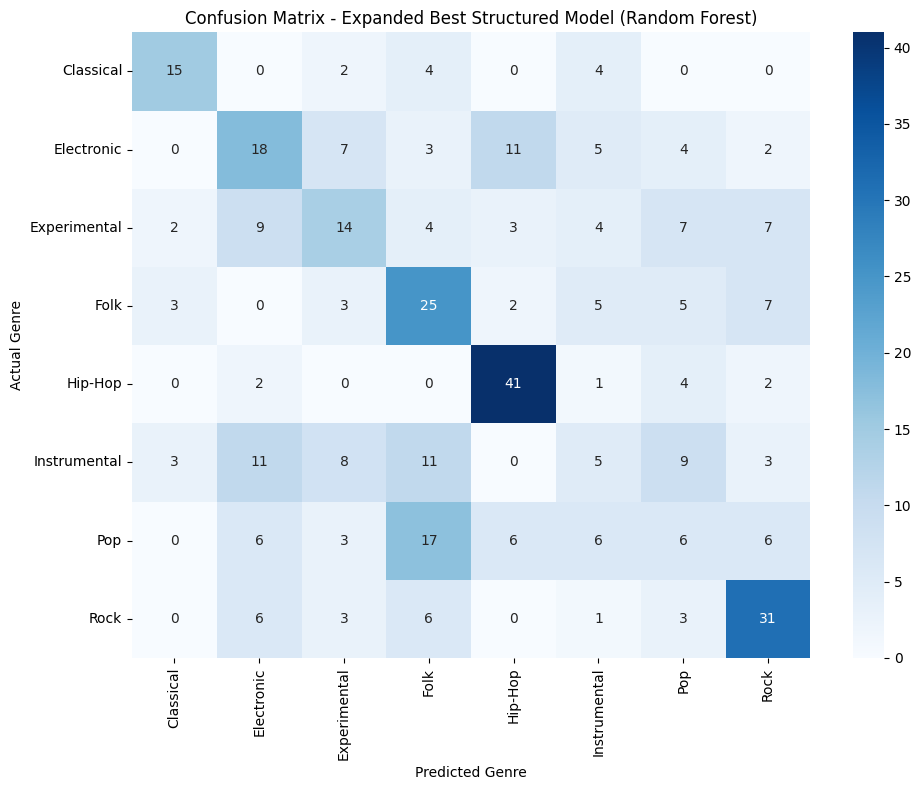

In [16]:
# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_test, test_pred_best)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Genre")
plt.ylabel("Actual Genre")
plt.title(f"Confusion Matrix - Expanded Best Structured Model ({best_model_name})")
plt.tight_layout()
plt.show()

Top 20 Important Features:
mfcc_max_04                    0.009353
rmse_std_01                    0.009331
spectral_contrast_median_04    0.008818
rmse_mean_01                   0.007639
spectral_contrast_mean_04      0.007106
mfcc_max_01                    0.006808
rmse_max_01                    0.006797
spectral_contrast_mean_03      0.006561
mfcc_min_01                    0.006463
tonnetz_std_05                 0.006374
mfcc_std_06                    0.006360
spectral_contrast_max_07       0.005604
spectral_contrast_median_03    0.005459
mfcc_median_03                 0.005442
tonnetz_std_06                 0.005409
rmse_median_01                 0.005320
spectral_contrast_median_02    0.005170
spectral_contrast_mean_05      0.004982
mfcc_mean_01                   0.004810
mfcc_mean_04                   0.004791
dtype: float64


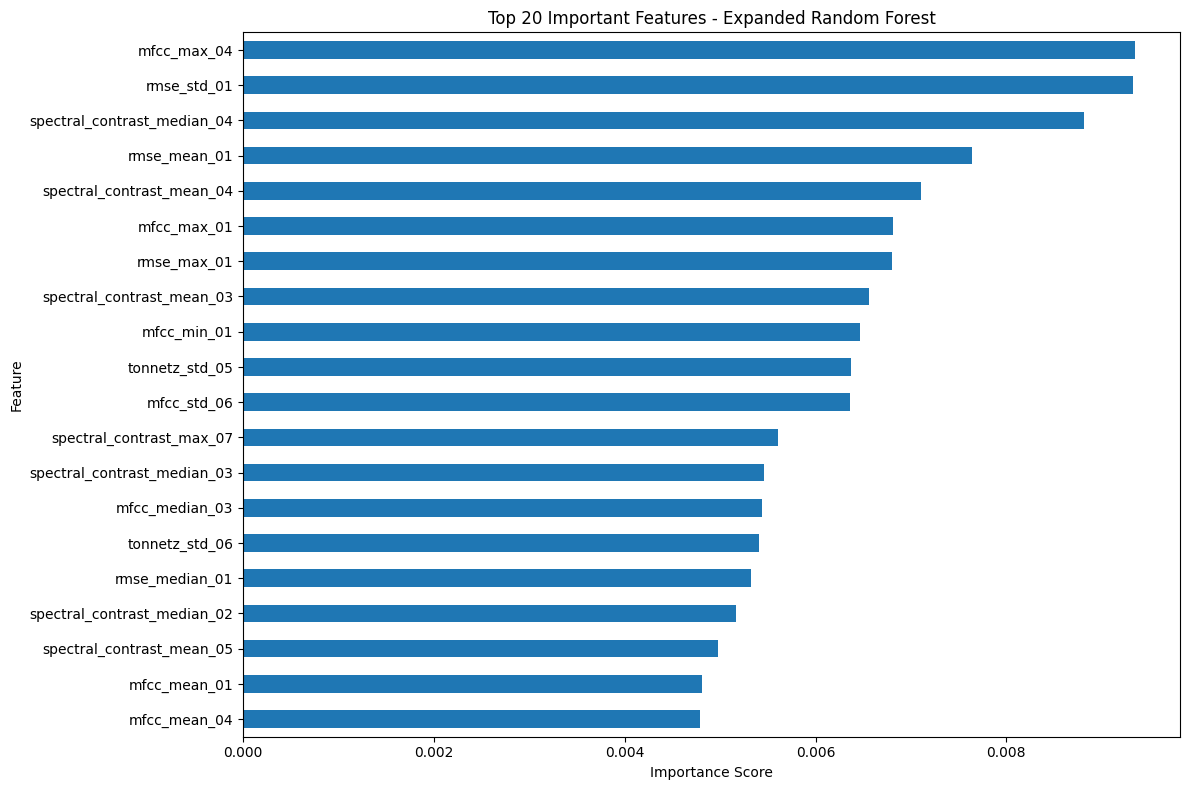

In [17]:
# ============================================================
# 17. FEATURE IMPORTANCE (IF RF IS BEST)
# ============================================================

if best_model_name == "Random Forest":
    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=X.columns
    )

    top_features = feature_importance.sort_values(ascending=False).head(20)

    print("Top 20 Important Features:")
    print(top_features)

    plt.figure(figsize=(12, 8))
    top_features.sort_values().plot(kind="barh")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.title("Top 20 Important Features - Expanded Random Forest")
    plt.tight_layout()
    plt.show()

In [18]:
# ============================================================
# 18. SAVE MODEL AND OUTPUTS
# ============================================================

os.makedirs("../models", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

joblib.dump(best_model, "../models/best_structured_model_expanded.joblib")

np.save("../data/processed/structured_feature_columns_expanded.npy", X.columns.to_numpy())

np.save("../data/processed/val_probs_lr_expanded.npy", val_probs_lr)
np.save("../data/processed/val_probs_rf_expanded.npy", val_probs_rf)
np.save("../data/processed/val_probs_svm_expanded.npy", val_probs_svm)

np.save("../data/processed/structured_test_probs_best_expanded.npy", test_probs_best)

np.save("../data/processed/y_val_structured_expanded.npy", y_val)
np.save("../data/processed/y_test_structured_expanded.npy", y_test)

np.save("../data/processed/structured_label_classes_expanded.npy", label_encoder.classes_)

with open("../data/processed/best_structured_model_name_expanded.txt", "w") as f:
    f.write(best_model_name)

with open("../data/processed/best_structured_model_test_accuracy_expanded.txt", "w") as f:
    f.write(str(structured_test_accuracy))

print("Saved expanded structured model and outputs.")

Saved expanded structured model and outputs.


In [19]:
# ============================================================
# 19. INTERPRETATION NOTES
# ============================================================

print("1. This notebook retrains the structured branch on the expanded 8-genre pilot.")
print("2. The goal is to see whether more training examples improve structured performance.")
print("3. The saved outputs will be used for expanded hybrid fusion.")
print("4. The next step is to compare this expanded structured model against the expanded CNN.")

1. This notebook retrains the structured branch on the expanded 8-genre pilot.
2. The goal is to see whether more training examples improve structured performance.
3. The saved outputs will be used for expanded hybrid fusion.
4. The next step is to compare this expanded structured model against the expanded CNN.
